## 1 | Introduction

This project is concerned with the problems of classifying whether a persons is a smoker from several biological variables. Our target variable is a binary variable, with value 1 representing a smoker and value 0 representing a non smoker. This project is also important theoritically as an example of classification when the target variable is impalanced. Our dataset consists of 55692 rows and 27 columns

In [147]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
import warnings
import plotly.express as px
import seaborn as sns
warnings.filterwarnings('ignore')

# 2 | EDA and Data Cleaning

Our independent variables were as follows:

In [125]:
data = pd.read_csv('smoking.csv')
print(data.columns.to_numpy())

['ID' 'gender' 'age' 'height(cm)' 'weight(kg)' 'waist(cm)'
 'eyesight(left)' 'eyesight(right)' 'hearing(left)' 'hearing(right)'
 'systolic' 'relaxation' 'fasting blood sugar' 'Cholesterol'
 'triglyceride' 'HDL' 'LDL' 'hemoglobin' 'Urine protein'
 'serum creatinine' 'AST' 'ALT' 'Gtp' 'oral' 'dental caries' 'tartar'
 'smoking']


In [119]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age,44552.0,44.210698,12.089196,20.0,40.0,40.0,55.0,85.0
height(cm),44552.0,164.657030,9.198674,130.0,160.0,165.0,170.0,190.0
weight(kg),44552.0,65.883462,12.823819,30.0,55.0,65.0,75.0,135.0
waist(cm),44552.0,82.077186,9.278384,51.0,76.0,82.0,88.0,129.0
eyesight(left),44552.0,1.011730,0.488136,0.1,0.8,1.0,1.2,9.9
eyesight(right),44552.0,1.008130,0.488767,0.1,0.8,1.0,1.2,9.9
hearing(left),44552.0,1.025611,0.157972,1.0,1.0,1.0,1.0,2.0
hearing(right),44552.0,1.026037,0.159247,1.0,1.0,1.0,1.0,2.0
systolic,44552.0,121.529179,13.688876,71.0,112.0,120.0,130.0,240.0
relaxation,44552.0,76.043320,9.695356,40.0,70.0,76.0,82.0,146.0


Most of our variables are continuous, except for the oral and tartar variables, which are categorical variables of cardinality 2. We will map both variables to the range $\{0, 1\}$.

In [152]:
data = pd.get_dummies(data=data, drop_first=True)
data = data.drop('ID', axis=1)

We will now check for null or duplicated values.

In [153]:
clean_info = pd.DataFrame(data = [data.isna().sum().sum(), data.duplicated().sum()], columns=['count'], index=['Null Values', 'Duplicated Values'])

clean_info

,count
Null Values,0
Duplicated Values,11140


We see that there is a great number of duplicated rows. We will assume that this wasn't done in bad faith, but that it was a simple mistake, and so shall not seek retribution. Instead, we will remove a single row from each pair of duplicates.

In [154]:
data = data.drop_duplicates()

In [155]:
data.iloc[3]

age                       40
height(cm)               165
weight(kg)                70
waist(cm)               88.0
eyesight(left)           1.5
eyesight(right)          1.5
hearing(left)            1.0
hearing(right)           1.0
systolic               100.0
relaxation              60.0
fasting blood sugar     96.0
Cholesterol            322.0
triglyceride           254.0
HDL                     45.0
LDL                    226.0
hemoglobin              14.7
Urine protein            1.0
serum creatinine         1.0
AST                     19.0
ALT                     26.0
Gtp                     18.0
dental caries              0
smoking                    0
gender_M                True
tartar_Y                True
Name: 3, dtype: object

In [53]:
data.iloc[46568]

age                       40
height(cm)               165
weight(kg)                70
waist(cm)               88.0
eyesight(left)           1.5
eyesight(right)          1.5
hearing(left)            1.0
hearing(right)           1.0
systolic               100.0
relaxation              60.0
fasting blood sugar     96.0
Cholesterol            322.0
triglyceride           254.0
HDL                     45.0
LDL                    226.0
hemoglobin              14.7
Urine protein            1.0
serum creatinine         1.0
AST                     19.0
ALT                     26.0
Gtp                     18.0
dental caries              0
smoking                    0
gender_M                True
tartar_Y                True
Name: 46568, dtype: object

Before doing any modelling, let's first see the distributions of our variables. First our target.

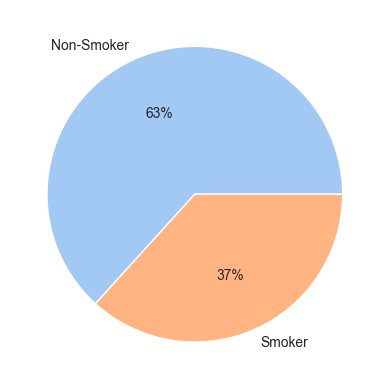

In [129]:
labels=['Non-Smoker', 'Smoker']

smoker_or_not = data['smoking'].value_counts().tolist()
values = [smoker_or_not[0], smoker_or_not[1]]

colors = sns.color_palette('pastel')[0:5]

plt.pie(values, labels = labels, colors = colors, autopct='%.0f%%')
plt.show()


For our independent variables:

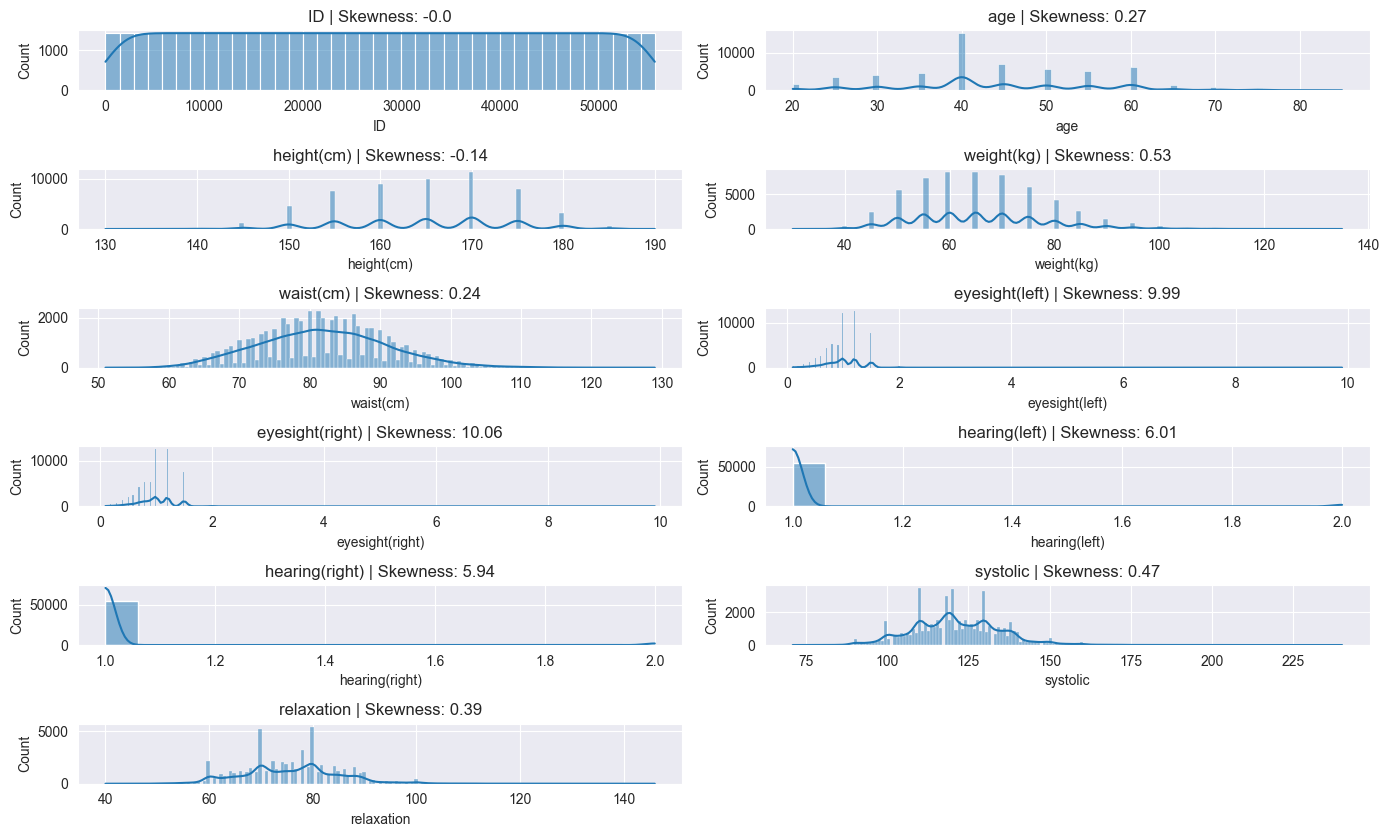

In [137]:
sns.set_style("darkgrid")

numerical_columns = data.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns[0:11]) * 3))
for idx, feature in enumerate(numerical_columns[0:11], 1):
	plt.subplot(len(numerical_columns), 2, idx)
	sns.histplot(data[feature], kde=True)
	plt.title(f"{feature} | Skewness: {round(data[feature].skew(), 2)}")

plt.tight_layout()
plt.show()


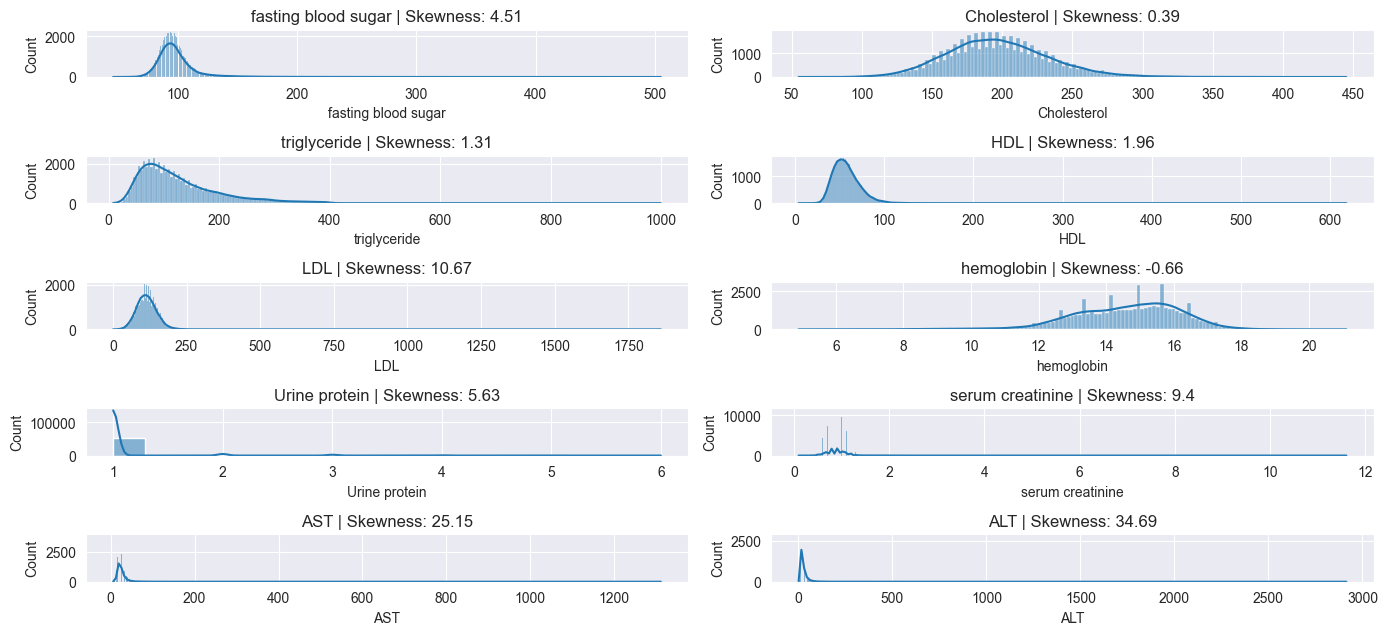

In [145]:
plt.figure(figsize=(14, len(numerical_columns[11:21]) * 3))
for idx, feature in enumerate(numerical_columns[11:21], 1):
	plt.subplot(len(numerical_columns), 2, idx)
	sns.histplot(data[feature], kde=True)
	plt.title(f"{feature} | Skewness: {round(data[feature].skew(), 2)}")

plt.tight_layout()
plt.show()


We see that several variables such as triglyceride and the hemoglobin are asymmetric.

In [156]:
y = data['smoking']
X = data.drop('smoking', axis=1)

# 3 | Feature Extraction

We added several new features features to the dataset:
1. BMI $= \frac{weight}{(height / 100)^2}$
2. BMI-age = $BMI \cdot age$
3. BMI-systolic = $BMI \cdot systolic$
4. waist-height = $waist \cdot height$
5. waist-weight = $waist \cdot weight$
6. Cholesterol-age = $Cholesterol \cdot age$


In [157]:
X['BMI'] =  X['weight(kg)'] / ((X['height(cm)'] / 100) ** 2)

# Interactions
X['BMI-age'] = X['BMI'] * X['age']
X['hemoglobin-age'] = X['hemoglobin'] * X['age']
X['BMI-systolic'] = X['BMI'] * X['systolic']
X['waist(cm)-height'] = X['waist(cm)'] * X['height(cm)']
X['waist(cm)-weight'] = X['waist(cm)'] * X['weight(kg)']
X['Cholesterol-age'] = X['Cholesterol'] * X['age']

# 4 | Feature Reduction

To measure the importance of the features, and to to decide which features should be dropped, we used information gain.

In [144]:
columns_to_drop = []
for column in X.columns:
    info_gain = mutual_info_score(y, X[column])
    if info_gain < 0.025:
        columns_to_drop.append(column)
    if info_gain > 0.05:
        print(f'Information gain: {column}: {info_gain}')

Information gain: height(cm): 0.1025396323516986
Information gain: weight(kg): 0.05516776595768156
Information gain: hemoglobin: 0.10277902589177144
Information gain: Gtp: 0.08026621305662589
Information gain: gender_M: 0.1548808809666915
Information gain: BMI: 0.10700846459952586
Information gain: BMI-age: 0.12089150957890596
Information gain: hemoglobin-age: 0.09411965838035596
Information gain: BMI-systolic: 0.15540487871614816
Information gain: waist(cm)-height: 0.1338476899000126
Information gain: waist(cm)-weight: 0.09015891331665868


The columns with too low information gain:

In [83]:
columns_to_drop

['age',
 'eyesight(left)',
 'eyesight(right)',
 'hearing(left)',
 'hearing(right)',
 'systolic',
 'relaxation',
 'fasting blood sugar',
 'Cholesterol',
 'HDL',
 'LDL',
 'Urine protein',
 'AST',
 'dental caries',
 'tartar_Y']

# 5 | Model 1: All features 

We split our dataset into train and test set of ratio $8:2$.

In [163]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [165]:
numeric_columns = X.select_dtypes(include=[float, int]).columns
ct = ColumnTransformer(
     [('standradize', StandardScaler(), numeric_columns),
     ], remainder='passthrough')

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

We standardized all the numerical variables before fitting the model. Our model will be a support vector machine with the radial basis function kernel, defined as follows: $$K(x_1, x_2) = e^{-\frac{||x_1 - x_2||^2}{2\alpha^2}}$$

This kernel defines an implicit, infinite dimensional features space of all possible polynomials of each variable. Basically it's as if, for each variable $x$, we added $x^2, x^3, x^4, ...$ as features to the dataset, though it gives lower and lower weight to higher order polynomials. All these facts follow directly from the taylor expansion of $e^x$.

We also did hyperparameter opimization, in order to find the best value for the $C$ parameter. We found that the best value for $C$ was 1. 

In [93]:
model = svm.SVC()
param_grid = {'C': [0.1, 1, 10, 100, 1000]}

grid = GridSearchCV(model,param_grid, cv=2)

In [94]:
grid.fit(X_train, y_train)

GridSearchCV(cv=2, estimator=SVC(), param_grid={'C': [0.1, 1, 10, 100, 1000]})

In [99]:
grid.best_estimator_

SVC(C=1)

In [100]:
model = svm.SVC(C=1)
model.fit(X_train, y_train)
test_preds = model.predict(X_test)

In [101]:
print(classification_report(y_test, test_preds))

              precision    recall  f1-score   support

           0       0.84      0.78      0.81      5646
           1       0.66      0.73      0.70      3265

    accuracy                           0.76      8911
   macro avg       0.75      0.76      0.75      8911
weighted avg       0.77      0.76      0.77      8911



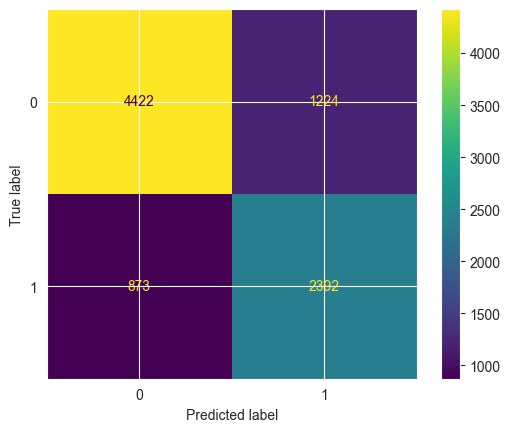

In [102]:
matrix = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(matrix).plot()

# 6 | Model 2: Dropped features with small information gain

In our second model, we dropped the features that had comparatively low information gain.

In [110]:
X_dropped = X.drop(columns_to_drop, axis=1)
X_train_dropped, X_test_dropped, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [111]:
model.fit(X_train_dropped, y_train)
test_preds = model.predict(X_test_dropped)
print(classification_report(y_test, test_preds))

              precision    recall  f1-score   support

           0       0.71      0.86      0.78      5646
           1       0.61      0.39      0.48      3265

    accuracy                           0.69      8911
   macro avg       0.66      0.62      0.63      8911
weighted avg       0.67      0.69      0.67      8911



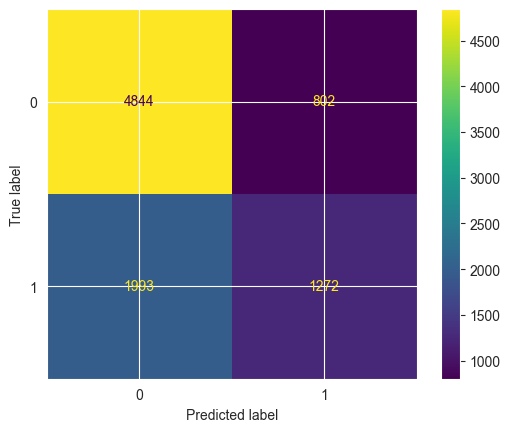

In [112]:
matrix = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(matrix).plot()

# 7 | Model 3: SVM with PCA

For our third model, we will use PCA for dimenionality reduction and then fit the model.

In [167]:
pca = PCA(n_components=31)
pca.fit(X_train)

PCA(n_components=31)

The following was the scree plot:

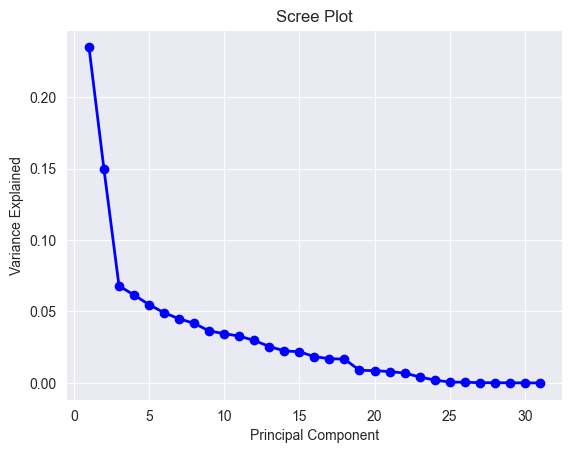

In [168]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

We see that the best number of variables is about $18$.

In [108]:
pca = PCA(n_components=17)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

In [114]:
model.fit(X_train, y_train)
test_preds = model.predict(X_test)
print(classification_report(y_test, test_preds))

              precision    recall  f1-score   support

           0       0.80      0.81      0.81      5646
           1       0.67      0.66      0.66      3265

    accuracy                           0.75      8911
   macro avg       0.73      0.73      0.73      8911
weighted avg       0.75      0.75      0.75      8911



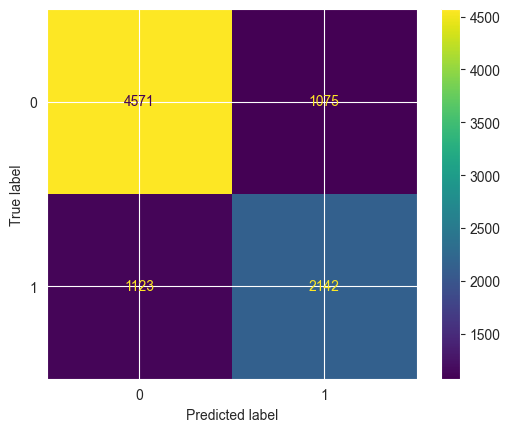

In [115]:
matrix = confusion_matrix(y_test, test_preds)
ConfusionMatrixDisplay(matrix).plot()